In [1]:
import matplotlib.pyplot as plt
from ase.db import connect
import pandas as pd
import numpy as np

# Figure 2b

Link dataset

In [2]:
db = connect(f'Data/Adss_data/train_data.db')

Count each adsorbate and adsorption site

In [3]:
adss_count = {
    'N2v  - top': 0,
    'N2h  - 4 fold': 0, 
    'NNHv - top': 0,
    'NNHh - hollow': 0,
    'NNHh - 4 fold': 0,
    'NH   - hollow': 0,
    'NH3  - top': 0,
    'H    - hollow': 0,
}
for row in db.select():
    struc_name = row.struc_name
    sys, adsb, rotate, site = struc_name.split('_')
    if   adsb == 'N2v' and site[-1] == 't':
        adss_count['N2v  - top'] += 1
    elif adsb == 'N2h' and site[-1] == 'b':
        adss_count['N2h  - 4 fold'] += 1
    elif adsb == 'NNHv' and site[-1] == 't':
        adss_count['NNHv - top'] += 1
    elif adsb == 'NNHh' and site[-1] == 'b':
        adss_count['NNHh - 4 fold'] += 1
    elif adsb == 'NNHh' and site[-1] == 'h':
        adss_count['NNHh - hollow'] += 1
    elif adsb == 'NH' and site[-1] == 'h':
        adss_count['NH   - hollow'] += 1
    elif adsb == 'NH3' and site[-1] == 't':
        adss_count['NH3  - top'] += 1
    elif adsb == 'H' and site[-1] == 'h':
        adss_count['H    - hollow'] += 1
    else:
        print(f'not found adss at {struc_name}')

Plot

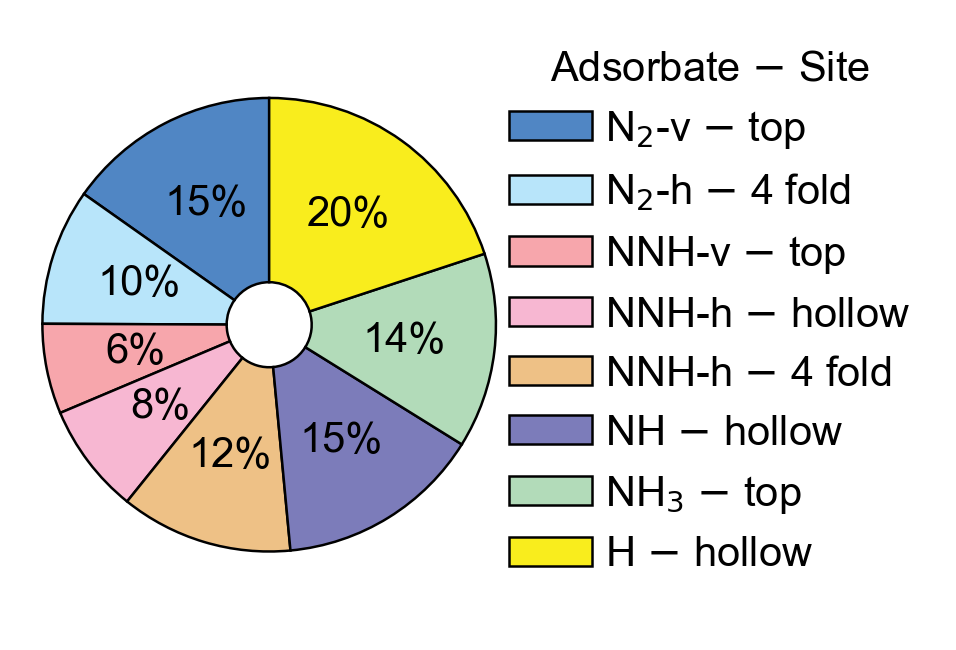

In [14]:
plt.rc('font', family='Arial')
fig=plt.figure(figsize=(7.5/2.54, 5/2.54), dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax=fig.add_axes([-0.03,0.2,0.6,0.6])
patches1, texts1, autotexts1=ax.pie(
    adss_count.values(),
    radius=1.6,
    wedgeprops=dict(width=1.3,edgecolor='k',lw=0.6),
    colors=['#5086C4','#B8E5FA','#F7A6AC','#F7B7D2','#EEC186', '#7C7CBA', '#B2DBB9', '#F9ED1D'],
    autopct="%1.0f%%",
    pctdistance=0.6,
    textprops={'fontsize':10,'color':'k','ha':'center'},
    startangle=90)#labels=Cadsb.keys(),labeldistance=1.08
labels = [
    'N$_2$-v $-$ top',
    'N$_2$-h $-$ 4 fold',
    'NNH-v $-$ top',
    'NNH-h $-$ hollow',
    'NNH-h $-$ 4 fold',
    'NH $-$ hollow',
    'NH$_3$ $-$ top',
    'H $-$ hollow'
]
ax.legend(patches1,labels,title='Adsorbate $-$ Site',fontsize=10,title_fontsize=10,loc=(1.13,-0.25),edgecolor='none',facecolor='none', handletextpad=0.3)

plt.show()
# fig.savefig('Figure_2_b.tif',dpi=300)

# Figure 2c

Read in data

In [2]:
df_train = pd.read_csv(f'Data/TrueVpred/train.csv', index_col=0)
df_test  = pd.read_csv(f'Data/TrueVpred/test.csv',  index_col=0)

In [3]:
predict_train = df_train['Gads_pred']
target_train = df_train['Gads_true']
predict_test = df_test['Gads_pred']
target_test = df_test['Gads_true']

Calculate difference between true and predicted values

In [4]:
diff_train = predict_train - target_train
diff_test = predict_test - target_test
print(max(diff_train), min(diff_train), max(diff_test), min(diff_test))

0.610011365 -0.49874383 0.68005275 -0.61191119


Count bins

In [5]:
bins=np.arange(-0.7,0.7,0.0125)

indices0=list(np.digitize(diff_train,bins))
counts0 = []
for b in range(len(bins)):
    counts0.append(indices0.count(b))
    
indices1=list(np.digitize(diff_test,bins))
counts1 = []
for b in range(len(bins)):
    counts1.append(indices1.count(b))

plot

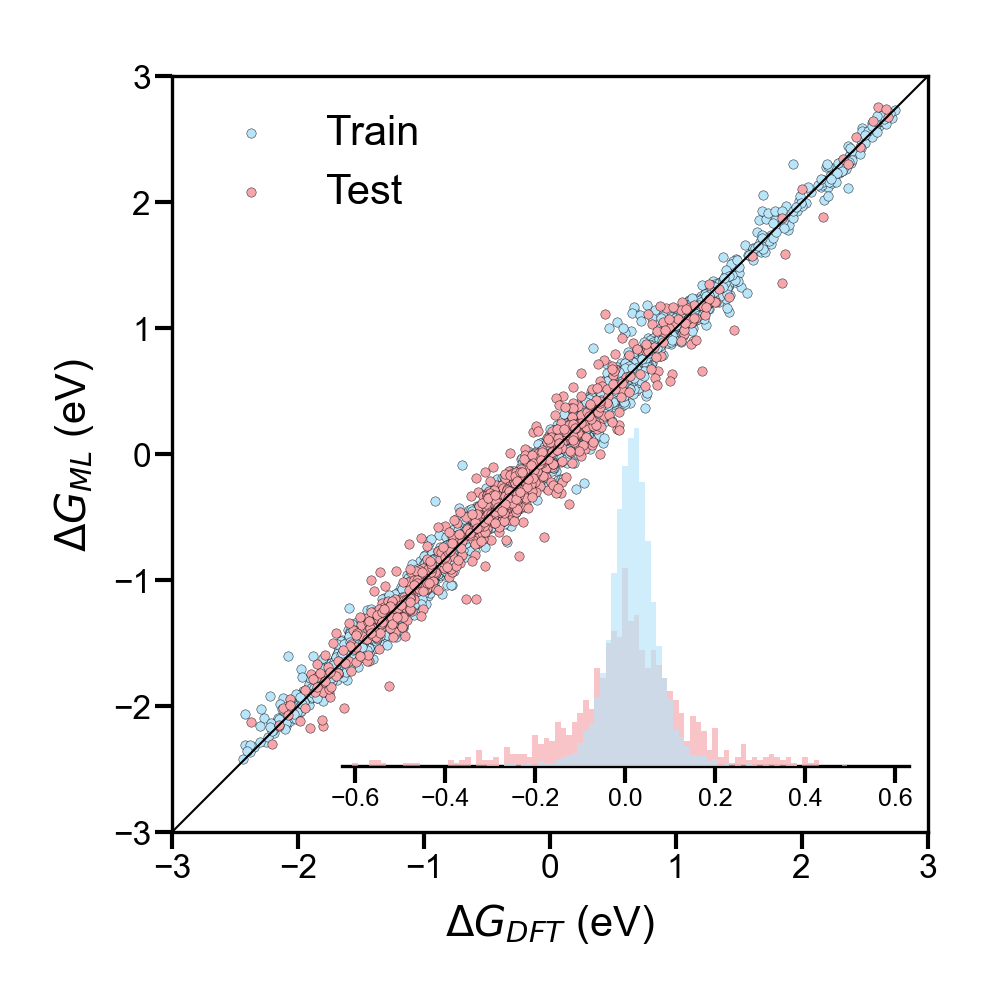

In [8]:
plt.rc('font',family='Arial')
fig=plt.figure(figsize=(8/2.54, 8/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)


ax=fig.add_axes([0.15, 0.15, 0.8, 0.8])
ax.tick_params(length=4,width=1,labelsize=8,pad=1)
ax.plot([-3,3], [-3,3], lw=0.5, ls='-', c='k', zorder=9)
# ax.plot([-3,3], [-3-0.14,3-0.14], lw=0.5, ls='--', c='k', zorder=9)
# ax.plot([-3,3], [-3+0.14,3+0.14], lw=0.5, ls='--', c='k', zorder=9)
ax.scatter(target_train, predict_train, label='Train', c='#B8E5FA', ec='k',lw=0.1, s=5, zorder=6)
ax.scatter(target_test, predict_test, label='Test', c='#F7A6AC', ec='k',lw=0.1, s=5, zorder=7)
ax.legend(fontsize=10,edgecolor='none',facecolor='none')
ax.set_xlabel('$\Delta G_{DFT}$ (eV)', fontsize=10)
ax.set_ylabel('$\Delta G_{ML}$ (eV)', fontsize=10)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

ax1=fig.add_axes([0.33, 0.22, 0.6, 0.4])
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([])
ax1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
ax1.bar(bins, counts1, width=1.4/len(bins), alpha=0.66, zorder=3, color='#F7A6AC')
ax1.tick_params(length=4,width=1,labelsize=6,pad=1)
ax1.patch.set_alpha(0.0)
ax1.set_xlim(-0.63, 0.63)
ax1.set_ylim(0, 120)

ax2=fig.add_axes([0.33, 0.22, 0.6, 0.4])
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.bar(bins, counts0, width=1.4/len(bins), alpha=0.66, zorder=6, color='#B8E5FA')
ax2.patch.set_alpha(0.0)
ax2.set_xlim(-0.63, 0.63)
ax2.set_ylim(0, 1000)

plt.show()
# fig.savefig('Figure_2_c.tif',dpi=300)